In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully! ✅")

Libraries loaded successfully! ✅


In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Dataset loaded! ✅")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded! ✅
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("=== Dataset Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Basic Statistics ===")
df.describe()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None

=== Missing Values ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.drop(columns=['Cabin'], inplace=True)
df.dropna(subset=['Embarked'], inplace=True)
df['Age'] = df['Age'].fillna(df['Age'].median())

print("Data cleaned! ✅")
print(f"New shape: {df.shape}")
print(f"Missing values remaining: {df.isnull().sum().sum()}")

Data cleaned! ✅
New shape: (889, 11)
Missing values remaining: 0


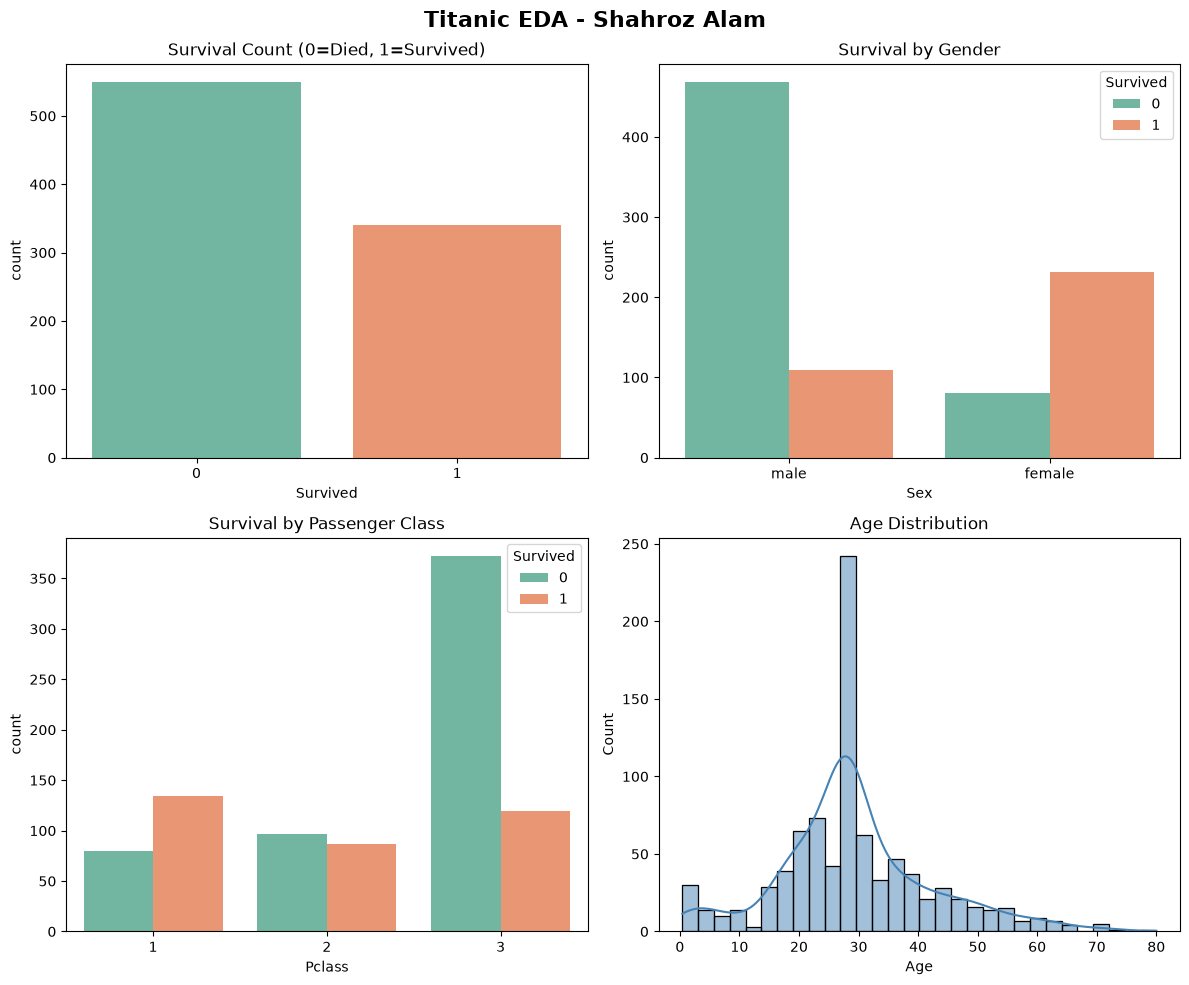

Visualizations saved! ✅


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Titanic EDA - Shahroz Alam', fontsize=16, fontweight='bold')

sns.countplot(x='Survived', hue='Survived', data=df, palette='Set2', ax=axes[0,0], legend=False)
axes[0,0].set_title('Survival Count (0=Died, 1=Survived)')

sns.countplot(x='Sex', hue='Survived', data=df, palette='Set2', ax=axes[0,1])
axes[0,1].set_title('Survival by Gender')

sns.countplot(x='Pclass', hue='Survived', data=df, palette='Set2', ax=axes[1,0])
axes[1,0].set_title('Survival by Passenger Class')

sns.histplot(df['Age'], bins=30, kde=True, color='steelblue', ax=axes[1,1])
axes[1,1].set_title('Age Distribution')

plt.tight_layout()
plt.savefig('titanic_eda.png')
plt.show()
print("Visualizations saved! ✅")

In [6]:
total = len(df)
survived = df['Survived'].sum()
survival_rate = (survived/total)*100

female_survival = df[df['Sex']=='female']['Survived'].mean()*100
male_survival = df[df['Sex']=='male']['Survived'].mean()*100

class1_survival = df[df['Pclass']==1]['Survived'].mean()*100
class3_survival = df[df['Pclass']==3]['Survived'].mean()*100

print("=" * 40)
print("📊 TITANIC EDA - KEY INSIGHTS")
print("=" * 40)
print(f"✅ Total Passengers  : {total}")
print(f"✅ Survived          : {survived} ({survival_rate:.1f}%)")
print(f"✅ Female Survival   : {female_survival:.1f}%")
print(f"✅ Male Survival     : {male_survival:.1f}%")
print(f"✅ 1st Class Survival: {class1_survival:.1f}%")
print(f"✅ 3rd Class Survival: {class3_survival:.1f}%")
print("=" * 40)
print("💡 Women and 1st class passengers survived more!")

📊 TITANIC EDA - KEY INSIGHTS
✅ Total Passengers  : 889
✅ Survived          : 340 (38.2%)
✅ Female Survival   : 74.0%
✅ Male Survival     : 18.9%
✅ 1st Class Survival: 62.6%
✅ 3rd Class Survival: 24.2%
💡 Women and 1st class passengers survived more!
